In [28]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7,5)
NAVY = "#004BA0"
GOLD = "#D1AB3E"

In [29]:
df = pd.read_csv("IPLPlayerStat.csv")
df.head()

,Unnamed: 0,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,0,A Ashish Reddy,280,31,196,18.0,270.0,400.0,28,10.00,142.86,15.82,8.89,22.22,15.00,8.0,0.0
1,1,A Badoni,161,18,139,2.0,12.0,12.0,11,14.64,115.83,12.95,6.00,6.00,6.00,8.0,0.0
2,2,A Chandila,4,0,7,11.0,234.0,245.0,12,0.33,57.14,0.00,6.28,22.27,21.27,2.0,0.0
3,3,A Chopra,53,7,75,0.0,0.0,0.0,6,8.83,70.67,9.33,0.00,0.00,0.00,2.0,0.0
4,4,A Choudhary,25,2,20,5.0,108.0,144.0,5,5.00,125.00,10.00,8.00,28.80,21.60,0.0,0.0


In [30]:
df.drop(columns=["Unnamed: 0"])

,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,A Ashish Reddy,280,31,196,18.0,270.0,400.0,28,10.00,142.86,15.82,8.89,22.22,15.00,8.0,0.0
1,A Badoni,161,18,139,2.0,12.0,12.0,11,14.64,115.83,12.95,6.00,6.00,6.00,8.0,0.0
2,A Chandila,4,0,7,11.0,234.0,245.0,12,0.33,57.14,0.00,6.28,22.27,21.27,2.0,0.0
3,A Chopra,53,7,75,0.0,0.0,0.0,6,8.83,70.67,9.33,0.00,0.00,0.00,2.0,0.0
4,A Choudhary,25,2,20,5.0,108.0,144.0,5,5.00,125.00,10.00,8.00,28.80,21.60,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600,Yash Dayal,0,0,1,11.0,205.0,296.0,9,0.00,0.00,0.00,8.66,26.91,18.64,1.0,0.0
601,Yashpal Singh,47,5,67,0.0,0.0,0.0,4,11.75,70.15,7.46,0.00,0.00,0.00,3.0,0.0
602,Younis Khan,3,0,7,0.0,0.0,0.0,1,3.00,42.86,0.00,0.00,0.00,0.00,1.0,0.0
603,Yuvraj Singh,2754,367,2207,36.0,882.0,1091.0,129,21.35,124.78,16.63,7.42,30.31,24.50,29.0,0.0


In [31]:
df.shape

(605, 17)

In [32]:
df["balls_faced"].describe()

count     605.000000
mean      373.477686
std       764.432561
min         1.000000
25%        18.000000
50%        73.000000
75%       285.000000
max      5266.000000
Name: balls_faced, dtype: float64

In [33]:
print(df.isnull().sum())

Unnamed: 0             0
player                 0
runs                   0
boundaries             0
balls_faced            0
wickets                0
balls_bowled           0
runs_conceded          0
matches                0
batting_avg            0
batting_strike_rate    0
boundaries_percent     0
bowling_economy        0
bowling_avg            0
bowling_strike_rate    0
catches                0
stumpings              0
dtype: int64


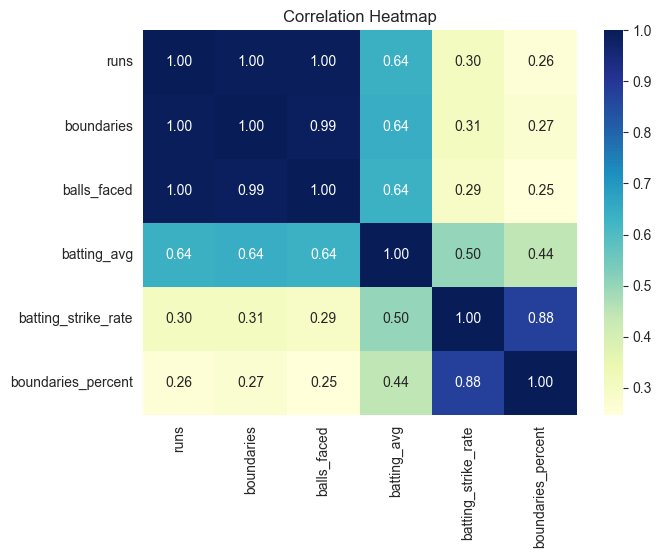

In [34]:
cols = ["runs", "boundaries", "balls_faced", "batting_avg", "batting_strike_rate", "boundaries_percent"]

plt.figure(figsize=(7,5))
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Correlation Heatmap")
plt.show()

In [35]:
X = df[["balls_faced"]]
y = df["runs"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept : ", round(model.intercept_, 2))
print("Slop : ", round(model.coef_[0], 4))
print(f"\nMeaning : every extra ball faced adds `{model.coef_[0]:.2f} runs on average . ")

Intercept :  -15.33
Slop :  1.2844

Meaning : every extra ball faced adds `1.28 runs on average . 


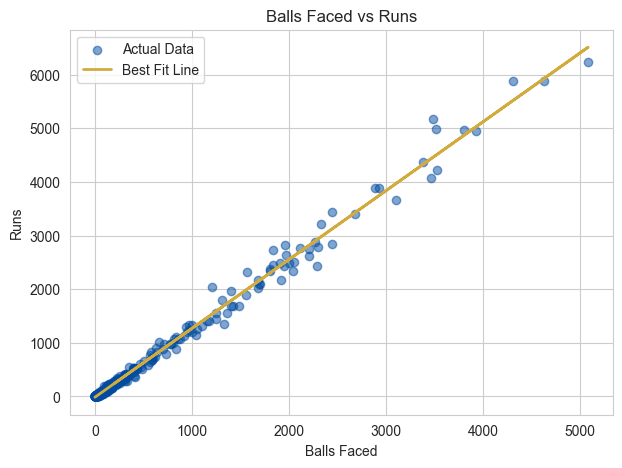

In [36]:
plt.figure(figsize=(7,5))
plt.scatter(X_train, y_train, color=NAVY, alpha=0.5, label= "Actual Data")
plt.plot(X_train, model.predict(X_train), color=GOLD, linewidth=2, label="Best Fit Line")
# plt.plot(X_train, y_train, color=GOLD, linewidth=2, label="Regression Line")
plt.xlabel("Balls Faced")
plt.ylabel("Runs")
plt.title("Balls Faced vs Runs")
plt.legend()

In [37]:
y_pred = model.predict(X_test)

comparision = pd.DataFrame({
    "balls_faced" : X_test["balls_faced"].values,
    "actual_runs": y_test.values,
    "predicted_runs" : np.round(y_pred, 1)
  })

comparision.head()

,balls_faced,actual_runs,predicted_runs
0,434,522,542.1
1,27,40,19.3
2,57,76,57.9
3,31,21,24.5
4,552,663,693.6


In [38]:
new_players = pd.DataFrame({"balls_faced" : [100,300,600]})
new_preds = model.predict(new_players)

for balls,runs in zip(new_players["balls_faced"], new_preds):
    print(f"Ball Faced = {balls} -> predicted runs = {runs:.0f}")

Ball Faced = 100 -> predicted runs = 113
Ball Faced = 300 -> predicted runs = 370
Ball Faced = 600 -> predicted runs = 755


## Multilinear Regression

In [39]:
features = ["balls_faced", "boundaries", "balls_bowled", "stumpings", "batting_strike_rate"]
X_multi = df[features]
y_multi = df["runs"]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size= 0.2, random_state=42)
multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
print("Intercet:", round(multi_model.intercept_,2))
for f, c in zip(features, multi_model.coef_):
    print(f"{f}: {c:.4f}")

Intercet: -18.07
balls_faced: 0.6805
boundaries: 3.5326
balls_bowled: 0.0045
stumpings: 2.2614
batting_strike_rate: 0.1359


In [41]:
y_pred_multi = multi_model.predict(X_test_m)
pd.DataFrame({"actual": y_test_m.values[:10], "predicted" : np.round(y_pred_multi[:10],1)})

,actual,predicted
0,522,513.3
1,40,41.6
2,76,75.0
3,21,19.3
4,663,649.4
5,985,989.7
6,34,36.4
7,12,9.8
8,20,17.0
9,920,873.4


In [1]:
def adjusted_r2(r2, n,p):
    # n = number of rows,  p= number of features
    return 1-((1-r2)*(n-1)/(n-p-1))

def evaluate(name, y_true, y_pred, n_features):  #y_true = y_test
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = adjusted_r2(r2, len(y_true), n_features)

    print(f"----{name}-----")
    print(f"MAE : {mae:.2f}")
    print(f"MSE : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2 : {r2:.4f}")
    print(f"Adjusted R2 : {adj_r2:.4f}\n")

    return {"model":name, "MAE" : mae, "MSE": mse, "RMSE" : rmse, "R2":r2, "Adj_R2":adj_r2}

results = []
results.append(evaluate("Simple Linear Regression", y_test, y_pred, n_features=1))
results.append(evaluate("Multiple Linear Regression", y_test, y_pred, n_features=7))

NameError: name 'y_test' is not defined